
## Multilingual Health QA - EDA



In [10]:
import pandas as pd

DATA_DIR = '/kaggle/input/datasets/sherylotieno/african-language-health'  

train = pd.read_csv(f'{DATA_DIR}/Train.csv')
test  = pd.read_csv(f'{DATA_DIR}/Test.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/SampleSubmission.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Sample sub shape:", sample_sub.shape)
print()
print("Train columns:", train.columns.tolist())
print()
train.head()

Train shape: (29815, 4)
Test shape : (2618, 3)
Sample sub shape: (2618, 4)

Train columns: ['ID', 'input', 'output', 'subset']



,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nn...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu...,"Wɔ Ghana mu no, amanmmra no gye binary gender ...",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔ...,Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔ...,Aka_Gha
3,ID_TR_Aka_Gha_BDD640FB,"Dɛn ne aduru a wodi si nyisɛn ano ntɛm ntɛm, n...",Aduru a wodi si nyisɛn ano ntɛm ntɛm (Emergen...,Aka_Gha
4,ID_TR_Aka_Gha_46685257,Hu sɛnea ɛyɛ den sɛ wubehu bɔbea mu basabasayɔ...,Ɛnyɛ mmerɛw bere nyinaa sɛ wubehu bɔbea mu bas...,Aka_Gha


In [11]:
print("=== Missing Values (Train) ===")
print(train.isnull().sum())
print()
print("=== Missing Values (Test) ===")
print(test.isnull().sum())
print()
print(f"Duplicate input questions  : {train['input'].duplicated().sum()}")
print(f"Duplicate output answers   : {train['output'].duplicated().sum()}")

=== Missing Values (Train) ===
ID        0
input     0
output    0
subset    0
dtype: int64

=== Missing Values (Test) ===
ID        0
input     0
subset    0
dtype: int64

Duplicate input questions  : 1469
Duplicate output answers   : 11737


## Language Distribution

There are 8 language subsets total, 4 African languages plus 4 English variants split by country. Below is how the samples break down across train and test.


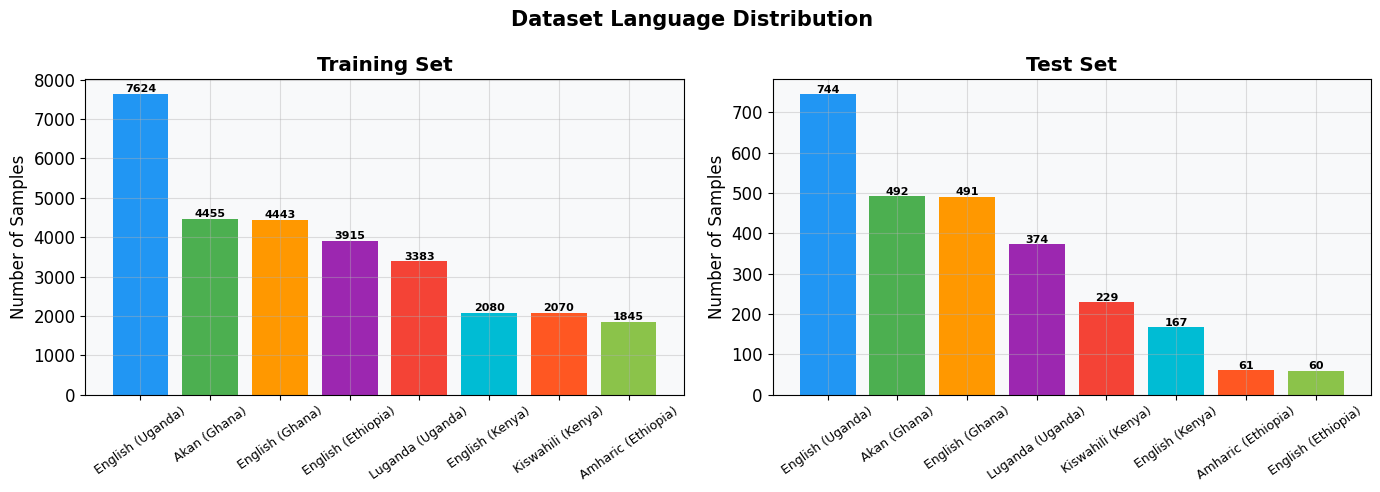


Train distribution:
subset
Eng_Uga    7624
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3915
Lug_Uga    3383
Eng_Ken    2080
Swa_Ken    2070
Amh_Eth    1845
Name: count, dtype: int64

Test distribution:
subset
Eng_Uga    744
Aka_Gha    492
Eng_Gha    491
Lug_Uga    374
Swa_Ken    229
Eng_Ken    167
Amh_Eth     61
Eng_Eth     60
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12,
})

lang_labels = {
    'Aka_Gha': 'Akan (Ghana)',
    'Amh_Eth': 'Amharic (Ethiopia)',
    'Eng_Eth': 'English (Ethiopia)',
    'Eng_Gha': 'English (Ghana)',
    'Eng_Ken': 'English (Kenya)',
    'Eng_Uga': 'English (Uganda)',
    'Lug_Uga': 'Luganda (Uganda)',
    'Swa_Ken': 'Kiswahili (Kenya)',
}
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#FF5722','#8BC34A']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Language Distribution', fontsize=15, fontweight='bold')

train_counts = train['subset'].value_counts()
axes[0].bar([lang_labels[k] for k in train_counts.index], train_counts.values, color=colors)
axes[0].set_title('Training Set', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=35, labelsize=9)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=8, fontweight='bold')

test_counts = test['subset'].value_counts()
axes[1].bar([lang_labels[k] for k in test_counts.index], test_counts.values, color=colors)
axes[1].set_title('Test Set', fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].tick_params(axis='x', rotation=35, labelsize=9)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTrain distribution:")
print(train_counts)
print("\nTest distribution:")
print(test_counts)

## Text Length Analysis

Question and answer lengths swing a lot depending on the language. That matters for choosing sensible `max_input_length` and `max_target_length` values once tokenization starts.


=== Input (Question) Word Count ===
count    29815.0
mean        15.1
std          9.1
min          0.0
25%          9.0
50%         13.0
75%         18.0
max         83.0
Name: input_word_len, dtype: float64

=== Output (Answer) Word Count ===
count    29815.0
mean        76.2
std         58.9
min          1.0
25%         30.0
50%         61.0
75%        107.0
max        482.0
Name: output_word_len, dtype: float64


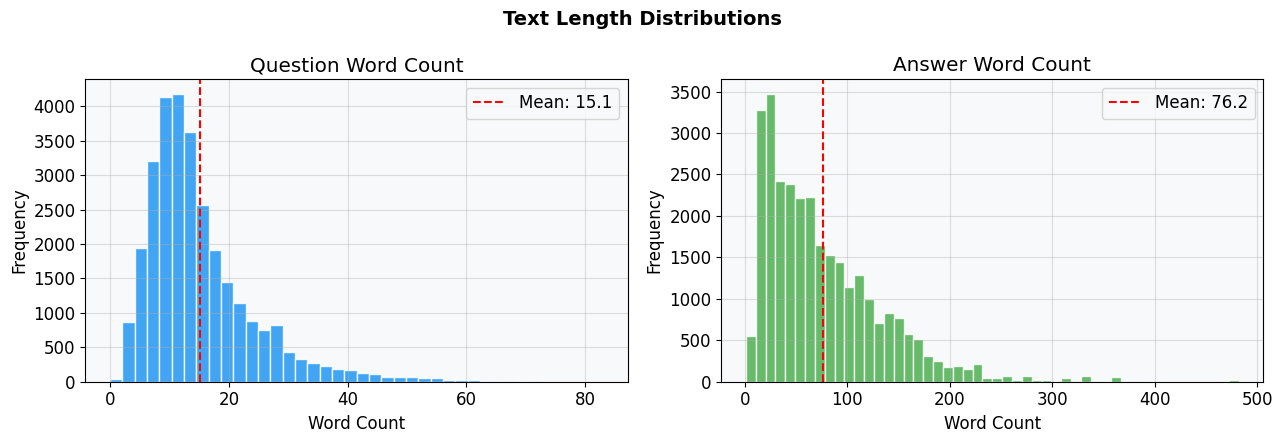

In [13]:
train['input_word_len']  = train['input'].str.split().str.len()
train['output_word_len'] = train['output'].str.split().str.len()

print("=== Input (Question) Word Count ===")
print(train['input_word_len'].describe().round(1))
print()
print("=== Output (Answer) Word Count ===")
print(train['output_word_len'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Text Length Distributions', fontsize=14, fontweight='bold')

axes[0].hist(train['input_word_len'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(train['input_word_len'].mean(), color='red', linestyle='--', label=f"Mean: {train['input_word_len'].mean():.1f}")
axes[0].set_title('Question Word Count')
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(train['output_word_len'], bins=50, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].axvline(train['output_word_len'].mean(), color='red', linestyle='--', label=f"Mean: {train['output_word_len'].mean():.1f}")
axes[1].set_title('Answer Word Count')
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Checking for empty or very short inputs


In [14]:
# Check empty or very short inputs
empty_inputs = train[train['input_word_len'] == 0]
print(f"Rows with 0-word input: {len(empty_inputs)}")
print(empty_inputs[['ID', 'input', 'output', 'subset']])

print()
short_inputs = train[train['input_word_len'] <= 2].sort_values('input_word_len')
print(f"\nRows with <=2 word input: {len(short_inputs)}")
print(short_inputs[['ID','input','input_word_len','subset']].head(10))

Rows with 0-word input: 1
                           ID input  \
18285  ID_TR_Eng_Uga_E9A002A4         

                                                  output   subset  
18285  Yes, when Gonorrhea is advanced it becomes har...  Eng_Uga  


Rows with <=2 word input: 40
                           ID               input  input_word_len   subset
18285  ID_TR_Eng_Uga_E9A002A4                                   0  Eng_Uga
2814   ID_TR_Aka_Gha_98C3E3CA                Popa               1  Aka_Gha
17627  ID_TR_Eng_Uga_F4DAFCC8           Syphilis?               1  Eng_Uga
2929   ID_TR_Aka_Gha_CCA1B45C                 343               1  Aka_Gha
17899  ID_TR_Eng_Uga_F9DA4F55               AIDS?               1  Eng_Uga
18323  ID_TR_Eng_Uga_CAC19D2E          Chlamydia?               1  Eng_Uga
23488  ID_TR_Eng_Uga_E8B2F81A          Gonorrhea?               1  Eng_Uga
6277   ID_TR_Amh_Eth_79A7E63B        ኤችአይቪ ምንድነዉ?               2  Amh_Eth
17120  ID_TR_Eng_Uga_2709F5B2         Group STIs.    

One row (`ID_TR_Eng_Uga_E9A002A4`) turned up with a completely empty input but a real output attached. Since there's nothing on the input side for the model to actually learn from, this one gets dropped before training. Worth noting that very short questions like "Syphilis?" or "AIDS?" are fine and should stay, those are real one-word questions, not broken rows.


#### Length breakdown by language


                    Avg_Q_Words  Avg_A_Words  Max_A_Words
Akan (Ghana)               28.8        105.6          458
English (Uganda)           11.2         95.4          482
Kiswahili (Kenya)          11.2         84.3          345
Luganda (Uganda)           10.5         79.7          331
English (Kenya)            11.4         78.7          315
English (Ghana)            20.0         75.1          408
English (Ethiopia)         12.2         24.5          118
Amharic (Ethiopia)          9.5         20.2          106


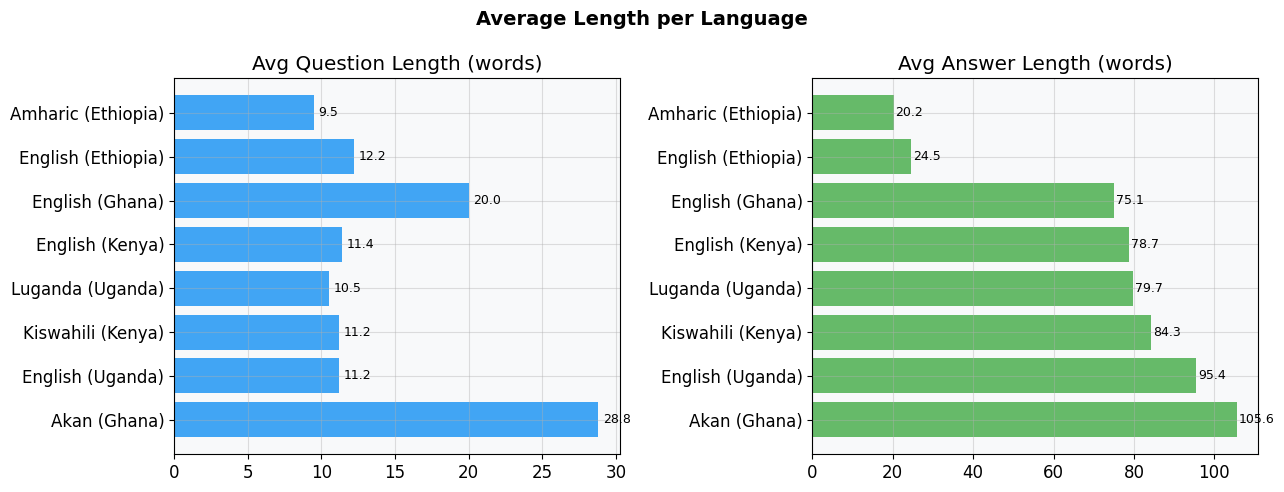

In [15]:
lang_stats = train.groupby('subset')[['input_word_len','output_word_len']].mean().round(1)
lang_stats.columns = ['Avg_Q_Words', 'Avg_A_Words']
lang_stats['Max_A_Words'] = train.groupby('subset')['output_word_len'].max()
lang_stats.index = [lang_labels[i] for i in lang_stats.index]
lang_stats = lang_stats.sort_values('Avg_A_Words', ascending=False)
print(lang_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Average Length per Language', fontsize=14, fontweight='bold')

axes[0].barh(lang_stats.index, lang_stats['Avg_Q_Words'], color='#2196F3', alpha=0.85)
axes[0].set_title('Avg Question Length (words)')
for i, v in enumerate(lang_stats['Avg_Q_Words']):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=9)

axes[1].barh(lang_stats.index, lang_stats['Avg_A_Words'], color='#4CAF50', alpha=0.85)
axes[1].set_title('Avg Answer Length (words)')
for i, v in enumerate(lang_stats['Avg_A_Words']):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### A few sample Q&A pairs per language


In [16]:
print("=" * 70)
for lang in sorted(train['subset'].unique()):
    label = lang_labels[lang]
    row = train[train['subset'] == lang].iloc[0]
    print(f"\n {label} — subset: {lang}")
    print(f"Q: {row['input'][:150]}")
    print(f"A: {row['output'][:150]}")
    print("-" * 70)


 Akan (Ghana) — subset: Aka_Gha
Q: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔan
A: Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛ
----------------------------------------------------------------------

 Amharic (Ethiopia) — subset: Amh_Eth
Q: የረጅም ጊዜ ጤናን በተመለከተ በጣም ሊያሳስበኝ የሚገቡ ሶስት ዋና ዋና ኢንፌክሽኖች የትኞቹ ናቸው?
A: ኤች አይ ቪ፣ ሄፓታይተስ ቢ እና ሂውማን ፓፒሎማ ቫይረስ (HPV)ናቸው።
----------------------------------------------------------------------

 English (Ethiopia) — subset: Eng_Eth
Q: How is syphilis diagnosed?
A: Blood tests like VDRL and RPR confirm syphilis infection.
----------------------------------------------------------------------

 English (Ghana) — subset: Eng_Gha
Q: What should I do if I have unprotected sex or experience a contraceptive failure?
A: If you have unprotected sex or experie

## Wrapping Up: What This Means for Preprocessing

Here's what came out of the EDA and what I'm doing about each thing:

| What I found | What it means for the pipeline |
|---|---|
| 8 subsets: 4 African languages (Akan, Amharic, Luganda, Kiswahili) plus 4 English variants | Need a multilingual model (mT5) that can actually handle all these scripts |
| Pretty unbalanced: Eng_Uga has 7,624 samples, Amh_Eth only has 1,845 | Track scores per language separately, Amharic will probably lag behind |
| Questions average around 15 words (max 83); answers average around 76 words (max 482) | `max_input_length=128`, `max_target_length=256` looks like a reasonable starting point |
| Akan has the longest Q&A pairs by far (avg Q=29 words, A=106 words) | May need a higher max_target_length (384 to 512) when batches are Akan-heavy |
| 1 row has an empty input but a valid output | Dropping that row during preprocessing |
| Roughly 39% of answers repeat across rows | Probably reflects standardised health guidance, lots of questions likely map to the same canned answer |
| No missing values otherwise | No imputation needed |

### Preprocessing plan going into `02_baseline.ipynb`
1. Drop the empty-input row
2. Strip leading/trailing whitespace from all text fields
3. Add a language-aware prompt prefix, e.g. `"answer health question: {question}"`
4. Tokenize with the mT5 tokenizer (it covers both Latin and Ge'ez/Ethiopic scripts)
5. Start with `max_input_length=128`, `max_target_length=256` and tune later
6. Do a stratified 90/10 train/validation split by `subset` so language balance is preserved


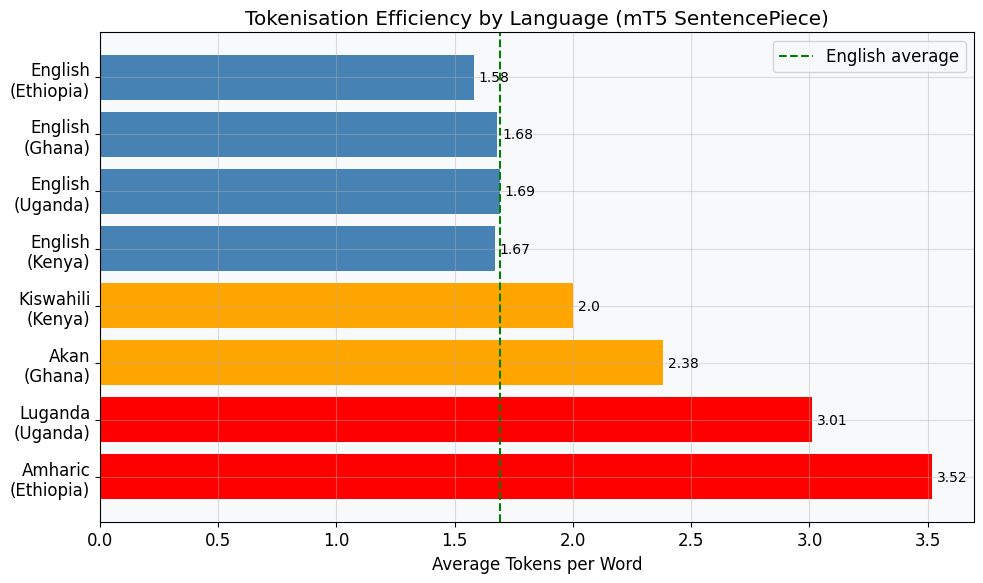

In [17]:
import matplotlib.pyplot as plt

languages = ['Amharic\n(Ethiopia)', 'Luganda\n(Uganda)', 'Akan\n(Ghana)', 
             'Kiswahili\n(Kenya)', 'English\n(Kenya)', 'English\n(Uganda)', 
             'English\n(Ghana)', 'English\n(Ethiopia)']
tokens_per_word = [3.52, 3.01, 2.38, 2.00, 1.67, 1.69, 1.68, 1.58]
colors = ['red' if t > 2.5 else 'orange' if t > 1.9 else 'steelblue' for t in tokens_per_word]

plt.figure(figsize=(10, 6))
bars = plt.barh(languages, tokens_per_word, color=colors)
plt.xlabel('Average Tokens per Word')
plt.title('Tokenisation Efficiency by Language (mT5 SentencePiece)')
plt.axvline(x=1.69, color='green', linestyle='--', label='English average')
for bar, val in zip(bars, tokens_per_word):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{val}', va='center', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('tokenisation.png', dpi=150, bbox_inches='tight')
plt.show()